In [1]:
# Chunk 1: Create splits directory and load engineered data
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Create directory if it doesn't exist
os.makedirs("../Data/Splits", exist_ok=True)

# Load engineered dataset
df = pd.read_csv("../Data/Engineered/Engineered.csv")
print("Dataset shape:", df.shape)
print("Class distribution:\n", df['is_drop'].value_counts())

Dataset shape: (2000, 28)
Class distribution:
 is_drop
0    1860
1     140
Name: count, dtype: int64


In [2]:
# Chunk 2: Separate features (X) and target (y)
X = df.drop('is_drop', axis=1)
y = df['is_drop']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 27)
Target shape: (2000,)


In [3]:
# Chunk 3: Split into train (70%) and temporary (30%)
RANDOM_STATE = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train)} (drops: {y_train.sum()})")
print(f"Temp size: {len(X_temp)} (drops: {y_temp.sum()})")

Train size: 1400 (drops: 98)
Temp size: 600 (drops: 42)


In [4]:
# Chunk 4: Split temp into validation (15% of original) and test (15% of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Validation size: {len(X_val)} (drops: {y_val.sum()})")
print(f"Test size: {len(X_test)} (drops: {y_test.sum()})")

Validation size: 300 (drops: 21)
Test size: 300 (drops: 21)


In [5]:
# Chunk 5: SMOTE on training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original train size: {len(X_train)} (drops: {y_train.sum()})")
print(f"SMOTE resampled train size: {len(X_train_smote)} (drops: {y_train_smote.sum()})")
print("New class balance:\n", pd.Series(y_train_smote).value_counts().to_dict())

Original train size: 1400 (drops: 98)
SMOTE resampled train size: 2604 (drops: 1302)
New class balance:
 {0: 1302, 1: 1302}


In [6]:
# Chunk 6: Save splits to ../Data/Splits/
# Original splits (without SMOTE)
X_train.to_csv("../Data/Splits/X_train.csv", index=False)
y_train.to_csv("../Data/Splits/y_train.csv", index=False)
X_val.to_csv("../Data/Splits/X_val.csv", index=False)
y_val.to_csv("../Data/Splits/y_val.csv", index=False)
X_test.to_csv("../Data/Splits/X_test.csv", index=False)
y_test.to_csv("../Data/Splits/y_test.csv", index=False)

# SMOTE resampled training data
X_train_smote.to_csv("../Data/Splits/X_train_smote.csv", index=False)
y_train_smote.to_csv("../Data/Splits/y_train_smote.csv", index=False)

print("All split files saved to ../Data/Splits/")

All split files saved to ../Data/Splits/


In [7]:
# Chunk 1: Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load original train (imbalanced)
X_train = pd.read_csv("../Data/Splits/X_train.csv")
y_train = pd.read_csv("../Data/Splits/y_train.csv")['is_drop']

# Load SMOTE resampled train (balanced)
X_train_smote = pd.read_csv("../Data/Splits/X_train_smote.csv")
y_train_smote = pd.read_csv("../Data/Splits/y_train_smote.csv")['is_drop']

print("Original train shape:", X_train.shape)
print("SMOTE train shape:", X_train_smote.shape)
print("\nOriginal class counts:\n", y_train.value_counts().to_dict())
print("\nSMOTE class counts:\n", y_train_smote.value_counts().to_dict())

Original train shape: (1400, 27)
SMOTE train shape: (2604, 27)

Original class counts:
 {0: 1302, 1: 98}

SMOTE class counts:
 {0: 1302, 1: 1302}


In [8]:
# Chunk 2: Combine both sets, scale, then reduce to 2D with PCA
# Add a label indicating which set each row comes from
X_train['source'] = 'original'
X_train_smote['source'] = 'smote'

# Combine
combined = pd.concat([X_train, X_train_smote], axis=0, ignore_index=True)
source = combined.pop('source')
y_combined = pd.concat([y_train, y_train_smote], axis=0, ignore_index=True)

# Scale features (PCA works better with scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(combined)

# PCA to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_)

Variance explained by PC1 and PC2: [0.2903391  0.09489488]


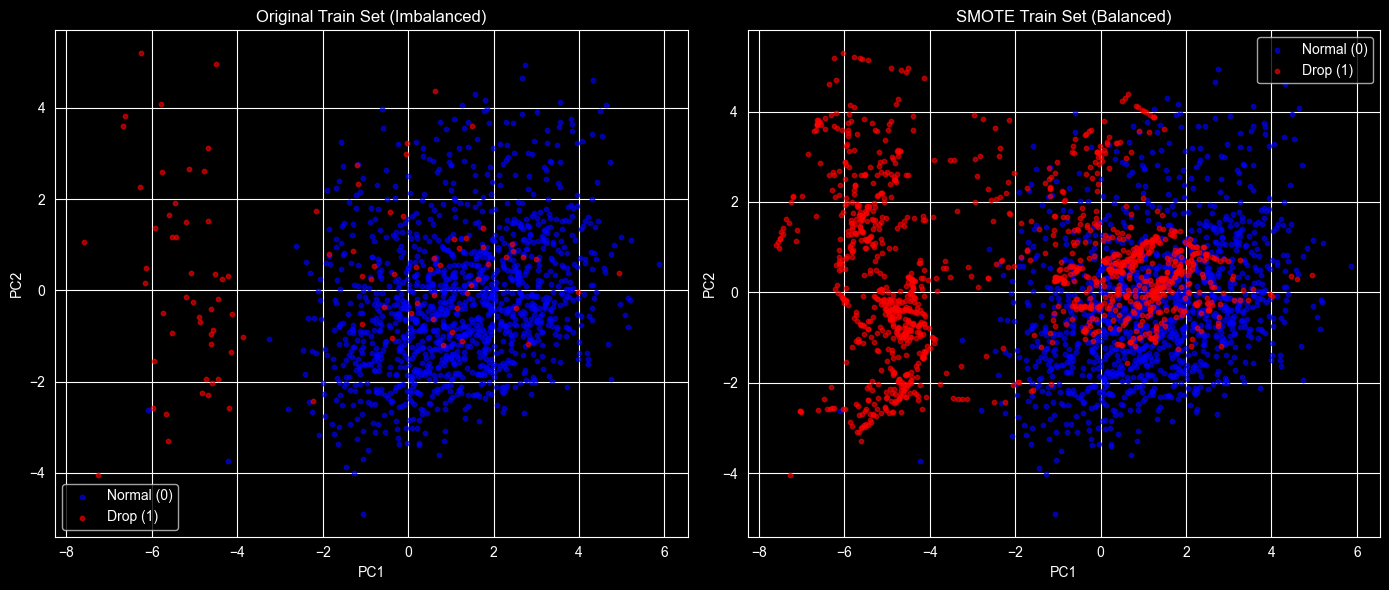

In [9]:
# Chunk 3: Visualize in 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data (imbalanced)
orig_mask = (source == 'original')
axes[0].scatter(X_pca[orig_mask & (y_combined==0), 0],
                X_pca[orig_mask & (y_combined==0), 1],
                c='blue', label='Normal (0)', alpha=0.6, s=10)
axes[0].scatter(X_pca[orig_mask & (y_combined==1), 0],
                X_pca[orig_mask & (y_combined==1), 1],
                c='red', label='Drop (1)', alpha=0.6, s=10)
axes[0].set_title('Original Train Set (Imbalanced)')
axes[0].legend()
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# SMOTE data (balanced)
smote_mask = (source == 'smote')
axes[1].scatter(X_pca[smote_mask & (y_combined==0), 0],
                X_pca[smote_mask & (y_combined==0), 1],
                c='blue', label='Normal (0)', alpha=0.6, s=10)
axes[1].scatter(X_pca[smote_mask & (y_combined==1), 0],
                X_pca[smote_mask & (y_combined==1), 1],
                c='red', label='Drop (1)', alpha=0.6, s=10)
axes[1].set_title('SMOTE Train Set (Balanced)')
axes[1].legend()
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

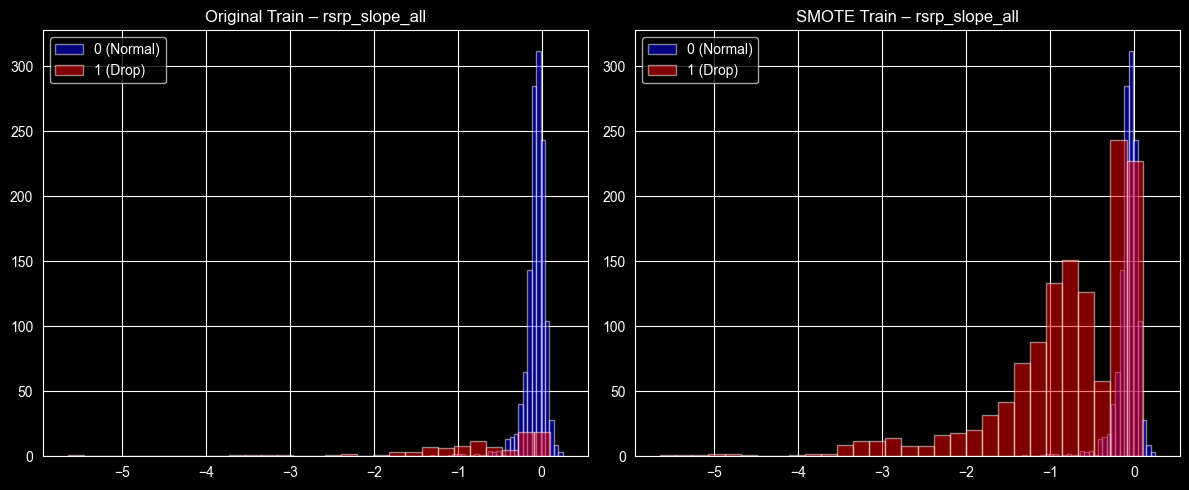

In [10]:
# Chunk 4: Compare distribution of one key feature before/after SMOTE
important_feat = 'rsrp_slope_all'  # change to any feature you like

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original train
for label, color in [(0, 'blue'), (1, 'red')]:
    subset = X_train[y_train == label][important_feat]
    axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=f'{label} ({"Normal" if label==0 else "Drop"})')
axes[0].set_title(f'Original Train – {important_feat}')
axes[0].legend()

# SMOTE train
for label, color in [(0, 'blue'), (1, 'red')]:
    subset = X_train_smote[y_train_smote == label][important_feat]
    axes[1].hist(subset, bins=30, alpha=0.5, color=color, label=f'{label} ({"Normal" if label==0 else "Drop"})')
axes[1].set_title(f'SMOTE Train – {important_feat}')
axes[1].legend()

plt.tight_layout()
plt.show()